<a href="https://colab.research.google.com/github/YuranShi/biostat-285-advanced-ml-dl/blob/main/hw2/biostat_285_homework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## BIOSTAT 285 Homework 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import NMF, PCA
from numpy.linalg import norm, eigh, svd
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import euclidean_distances
from scipy.linalg import fractional_matrix_power
from PIL import Image
import requests
from io import BytesIO

### Problem 1: Non-linear clustering and data connectivity

Load the data `halfmoon.csv` and `bullseye.csv`. Each data set has two features $X_1$ and $X_2$ and true
label for each instance which you will use to compare the performance of the clustering algorithm.
Do the following for each of the two data sets:

1. Plot each of the dataset and comment on any patterns or clusters that are visually obvious.

2. Fit k-means++ and comment on the fit.

3. **k-nearest neighbor graph**:
* For the $n$ instances, construct the $n \times n$ Adjacency Matrix $A$ as follows:
$$A_{ij}= \begin{cases} 1 & \text{if } j \text{ is one of the } m \text{ nearest neighbors of } i \text{ or } i \text{ is one of the } m \text{ nearest neighbors of } j, \\ 0 & \text{otherwise} \end{cases}$$
* Compute the Graph Laplacian $L = D - A$ where $D$ is diagonal with each diagonal element equal to the corresponding row sum of $A$.
* Perform an eigendecompostion of $L$, sort the eigenvalues and retrieve the second smallest eigenvalue and corresponding eigenvector. Treat each element of this $n \times 1$ eigenvector as new versions of your instances/observations.
* Fit k-means to this transformed data.
* Repeat the steps above for $m \in \{5, 10, 15, 20\}$, choose the one that gives the best fit and comment on the fit.

4. **Weighted distance graph**:
* For $n$ instances, construct the $n \times n$ affinity matrix $A$ as follows:
$$A_{ij}= \begin{cases} \exp\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right) & \text{if } i \neq j \\ 0 & \text{otherwise} \end{cases}$$
Fix $\sigma^2 = 0.1$ for the bull’s eye data and $\sigma^2 = 0.01$ for the halfmoons data.
* Form the diagonal matrix $D$ such that the $i$th diagonal element is the row sum of the $i$th $A$.
* Construct the matrix $L = D^{-1/2}AD^{-1/2}$
* Find $e_1, \dots, e_m$, the eigenvectors corresponding to the $m$ largest eigenvalues of $L$ (chosen to be orthogonal in case of repeated eigenvalues) and form the $n \times m$ matrix $U$ by stacking the $m$ eigenvectors as columns of $U$.
* Form the matrix $V$ from $U$ by normalizing each row of $U$ to have unit length:
$$V_{ij} = \frac{U_{ij}}{\sqrt{\sum_{\ell=1}^m U_{i\ell}^2}}$$
* Treat the rows of $V$ as new versions of your instances/observations, and apply k-means with $m$ clusters to the rows of $V$.
* Finally, assign labels to each of the original instances $x_i$ to cluster $j$ if row $i$ of $V$ was assigned to cluster $j$.
* Repeat the steps above for $m \in \{5, 10, 15, 20\}$, choose the one that gives the best fit and comment on the fit.

##### **Non-linear clustering of `halfmoon.csv`**

1. Plot dataset and observe **patterns**

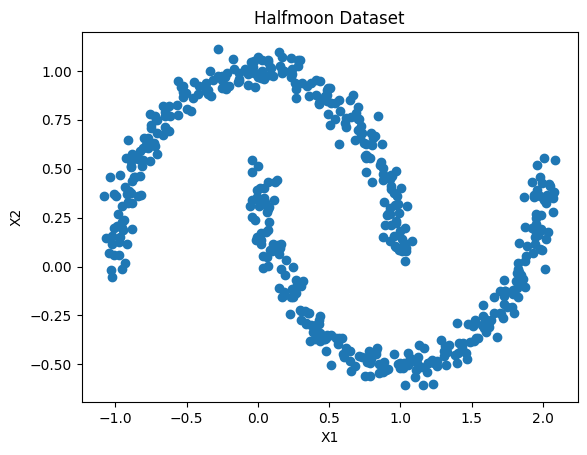

In [ ]:
halfmoon_url = "https://raw.githubusercontent.com/YuranShi/biostat-285/refs/heads/main/hw2/halfmoon.csv"
halfmoon = pd.read_csv(halfmoon_url)

plt.scatter(halfmoon['X1'], halfmoon['X2'])
plt.title('Halfmoon Dataset')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

> Based on the plot, we can observe that the data consists of one inverse U-shaped cluster and one upright U-shaped cluster (just like  "half moons"). It seem to be very hard to separate these clusters using straight lines.

2. Fit kmeans++

In [ ]:
# Helper function
def plot_cluster_results(X, label, method):
    """ Plot cluster result using scatter plot with colors
    X: input data
    label: clustering labels
    method (str): method that is used for clustering
    """
    plt.scatter(X['X1'], X['X2'], c=label, cmap='viridis')
    plt.title(f'Clustering Results ({method})')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.show()

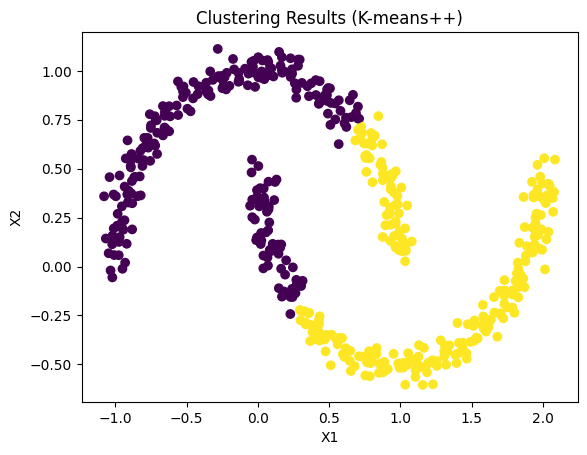

In [ ]:
X = halfmoon[['X1', 'X2']]
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=1)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Plot clusters
plot_cluster_results(X, y_kmeans, "K-means++")

> Based on the clustering result, we can observe that kmeans++ cannot cluster our data very well. Since kmeans is a linear algorithm, it often cannot handle data with non-linearity. To better cluster the halfmoon data, we need to use non-linear cluster algorithms.

3. k-nearest neighbor graph:

In [ ]:
# Helper functions
def get_knn_adjacency(X, m):
    n = X.shape[0]
    # get pairwise distance
    dist_matrix = cdist(X, X, metric="euclidean")

    A = np.zeros((n, n))
    for i in range(n):
        indices = np.argsort(dist_matrix[i])[1:m+1]
        A[i, indices] = 1

    # Make A symmetric
    A = np.maximum(A, A.T)
    return A


def get_knn_laplacian(A):
    degrees = np.sum(A, axis=1)
    D = np.diag(degrees)
    L = D - A
    return L


def get_fiedler_vector(L):
    eigenvalues, eigenvectors = eigh(L)

    # Sort them (eigh usually returns them sorted, but let's be safe)
    idx = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Retrieve the second smallest eigenvalue and its eigenvector
    fiedler_vector = eigenvectors[:, 1].reshape(-1, 1)
    return fiedler_vector

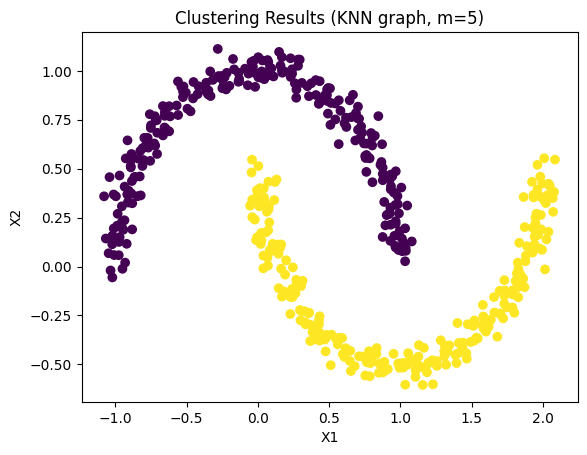

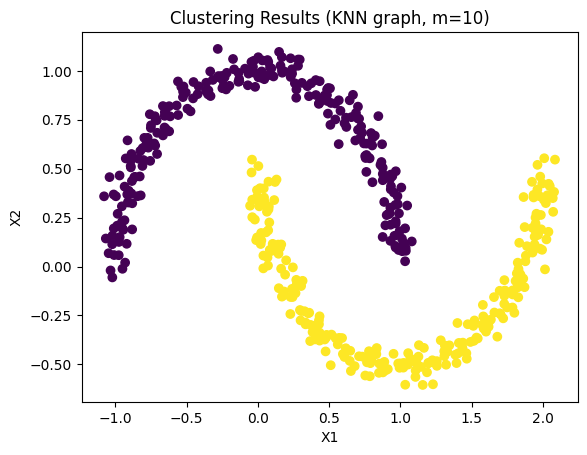

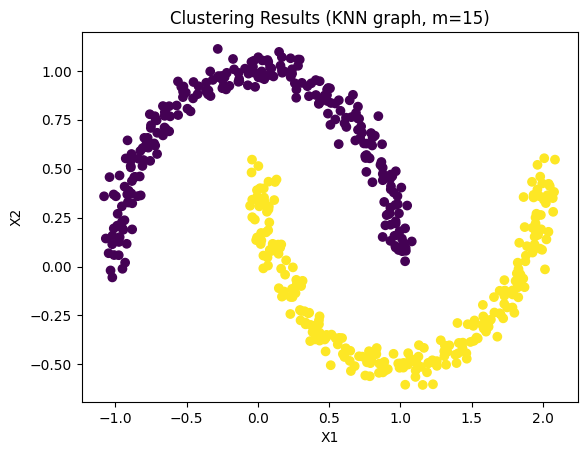

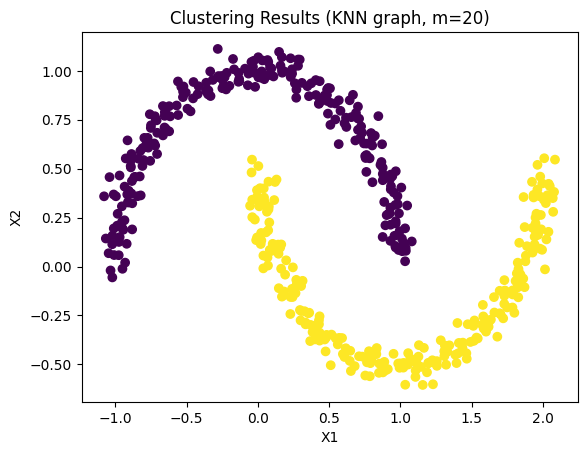

In [ ]:
m_values = [5, 10, 15, 20]

for m in m_values:
    A = get_knn_adjacency(X, m)
    L = get_knn_laplacian(A)
    fiedler_vector = get_fiedler_vector(L)

    # Fit k-means to transformed data (the Fiedler vector)
    kmeans = KMeans(n_clusters=2, n_init=10)
    labels = kmeans.fit_predict(fiedler_vector)

    # Plot cluster results
    plot_cluster_results(X, labels, method=f"KNN graph, m={m}")

> Based on the above results $m \in \{5, 10, 15, 20\}$, all the m values partitioned data correctly. KNN introduced non-linearity into clustering, and thus partitioned halfmoon dataset more effectively.

4. Weighted distance graph:

In [ ]:
# Helper function for weighted distance graph
def get_wdg_laplacian(X, sigma_sq):
    """
    X (pandas.Dataframe): input data
    sigma_sq (float): sigma square of dataset.
    """
    # Calculate affinity matrix
    n = X.shape[0]
    dist_matrix = euclidean_distances(X, X) # Get the pairwise euclidean distance
    A = np.exp(-dist_matrix / (2 * sigma_sq))

    # Calculate diagonal matrix D
    degrees = np.sum(A, axis=1)
    # D = np.diag(degrees)

    # Construct L = D^-1/2 * A * D^-1/2
    d_inv_sqrt = 1.0 / np.sqrt(degrees)
    L = d_inv_sqrt[:, np.newaxis] * A * d_inv_sqrt[:, np.newaxis]
    return L


def get_normalized_embedding(L, m):
    eigenvalues, eigenvectors = eigh(L)

    # Get indices of m largest eigenvalues and construct U
    idx = np.argsort(eigenvalues)[-m:]
    U = eigenvectors[:, idx]

    # Normalize rows of U to construct V
    row_norms = np.linalg.norm(U, axis=1, keepdims=True)
    V = U / (row_norms + 1e-10) # avoid division by zero
    return V


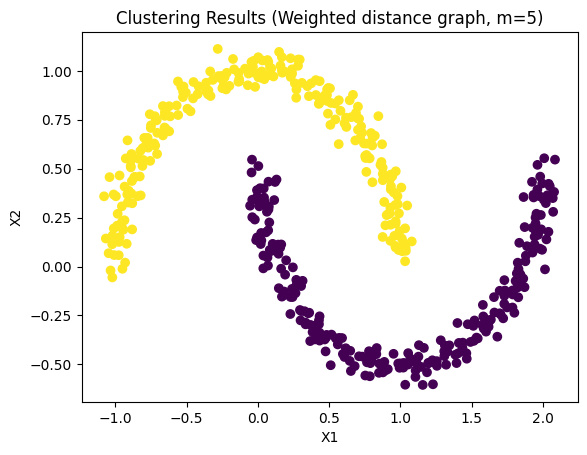

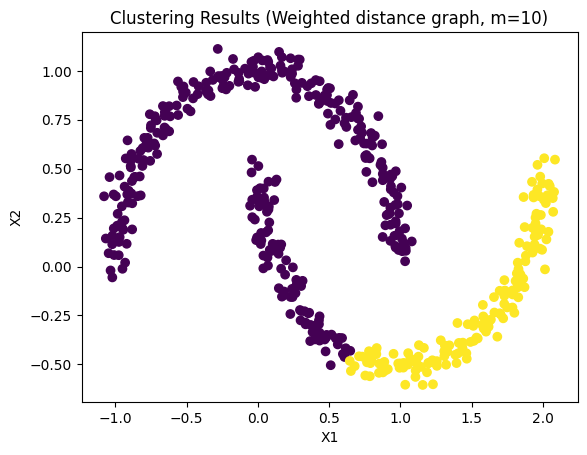

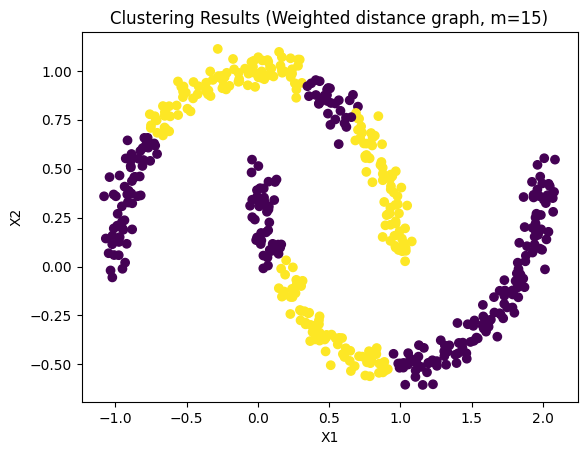

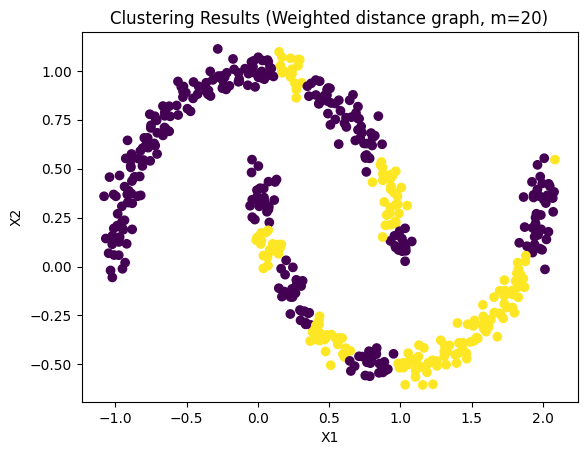

In [ ]:
m_values = [5, 10, 15, 20]

for m in m_values:
    # Fix σ2 = 0.1 for the bull’s eye data and σ2 = 0.01 for the halfmoons data.
    sigma_sq = 0.01
    L = get_wdg_laplacian(X, sigma_sq)
    V = get_normalized_embedding(L, m)

    # Fit k-means to V
    kmeans = KMeans(n_clusters=2, n_init=10)
    labels = kmeans.fit_predict(V)

    # Plot cluster results
    plot_cluster_results(X, labels, method=f"Weighted distance graph, m={m}")

> Based on the above results, smaller value of m achieve better partition. In this case, $m=5$ and $m=10$ give correct clustering results, whereas $m=15$ and $m=20$ partition data into smaller clusters.

##### **Non-linear clustering of `bullseye.csv`**

1. Plot dataset and observe **patterns**

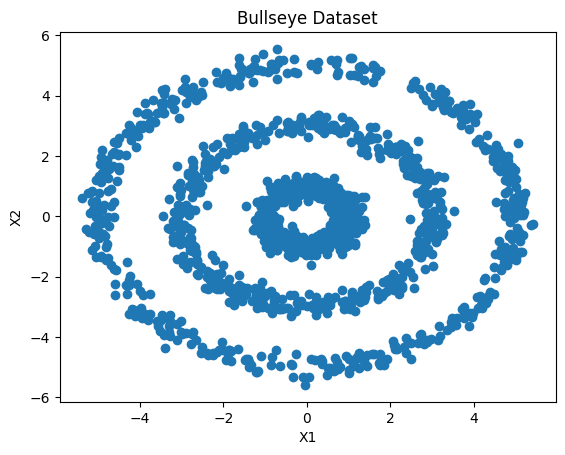

In [ ]:
bullseye_url = "https://raw.githubusercontent.com/YuranShi/biostat-285/refs/heads/main/hw2/bullseye.csv"
bullseye = pd.read_csv(bullseye_url)

# Plotting
plt.scatter(bullseye['X1'], bullseye['X2'])
plt.title('Bullseye Dataset')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

> Based on the plot, we can observe that the data is consists of three circles. Similar to the halfmoon data, it seem to be very hard to separate these clusters using straight lines.

2. Fit kmeans++

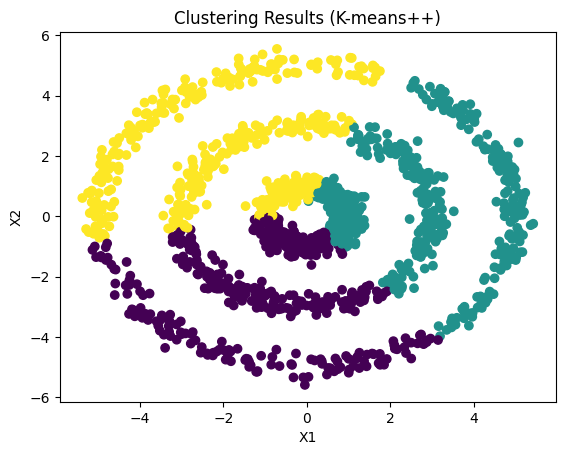

In [ ]:
X = bullseye[['X1', 'X2']]
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=1)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Plot clusters
plot_cluster_results(X, y_kmeans, method="K-means++")

> Based on the clustering result, we can observe that kmeans++ cannot cluster our data very well. Since kmeans is a linear algorithm, it often cannot handle data with non-linearity. To better cluster the halfmoon data, we need to use non-linear cluster algorithms.

3. k-nearest neighbor graph:

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


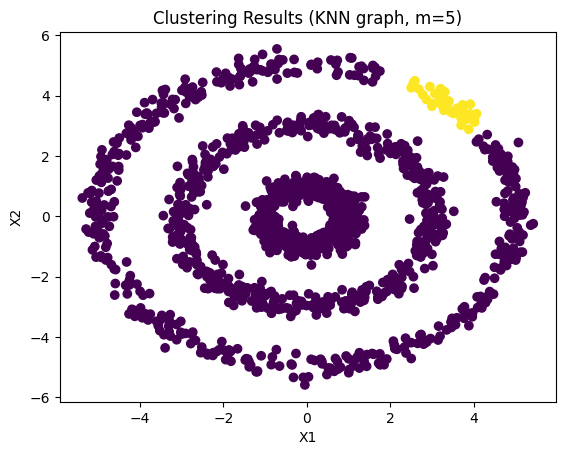

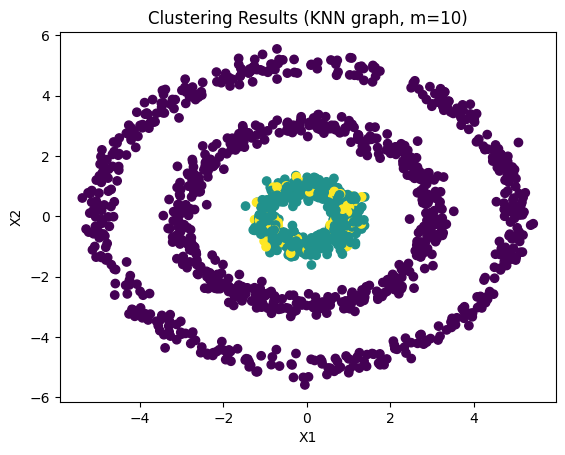

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


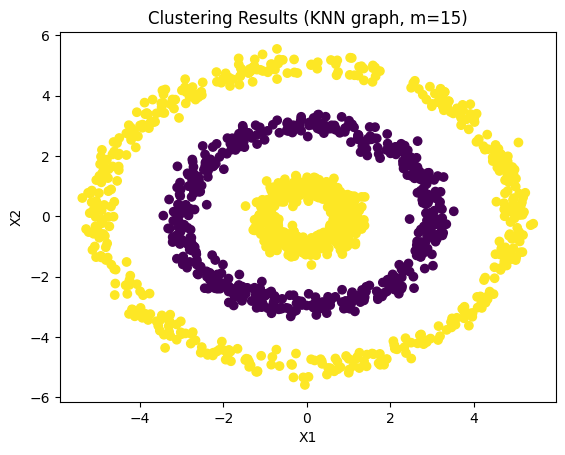

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


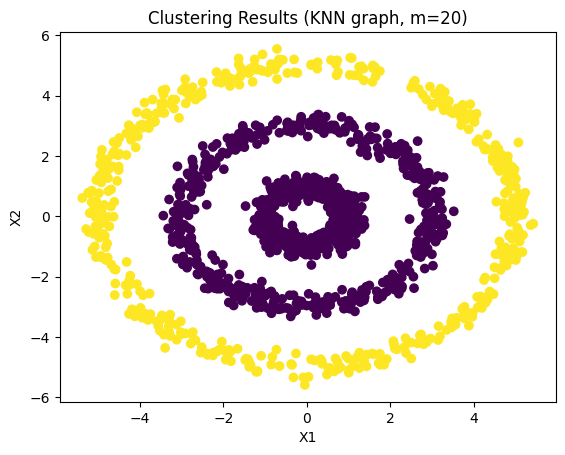

In [ ]:
# We can directly use the help function above
m_values = [5, 10, 15, 20]

for m in m_values:
    A = get_knn_adjacency(X, m)
    L = get_knn_laplacian(A)
    fiedler_vector = get_fiedler_vector(L)

    # Fit k-means to transformed data (the Fiedler vector)
    kmeans = KMeans(n_clusters=3, n_init=10)
    labels = kmeans.fit_predict(fiedler_vector)

    # Plot cluster results
    plot_cluster_results(X, labels, method=f"KNN graph, m={m}")

> Based on the clustering results above, KNN graph only partitions data into two distinct classes, no matter the value of m. This is likely because we are only using the 2nd eigenvector in the algorithm, which split the data into two parts.

4. Weighted distance graph:

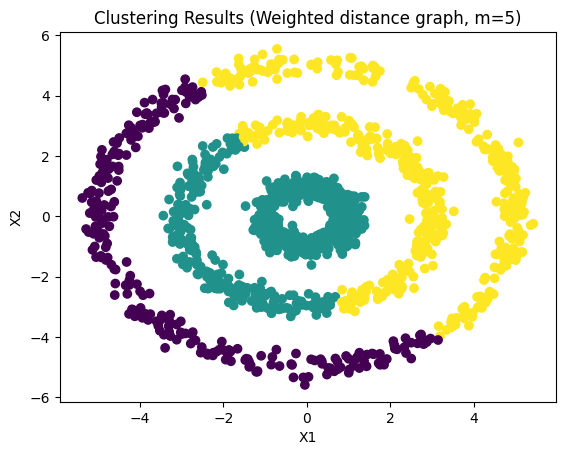

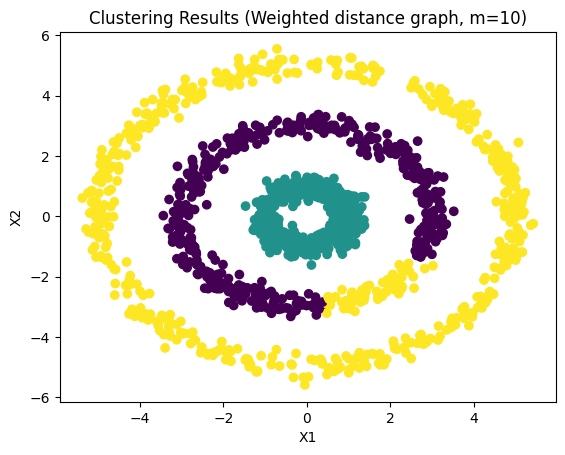

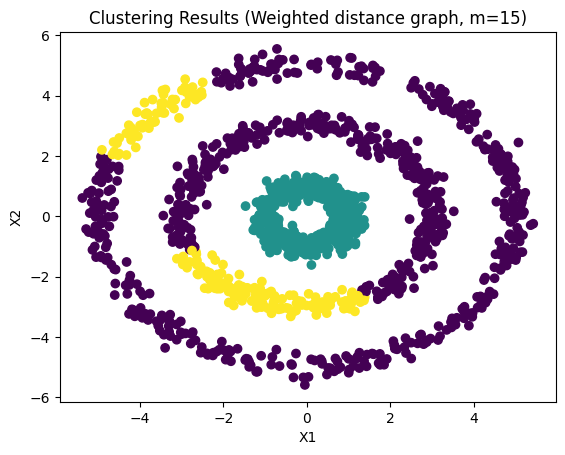

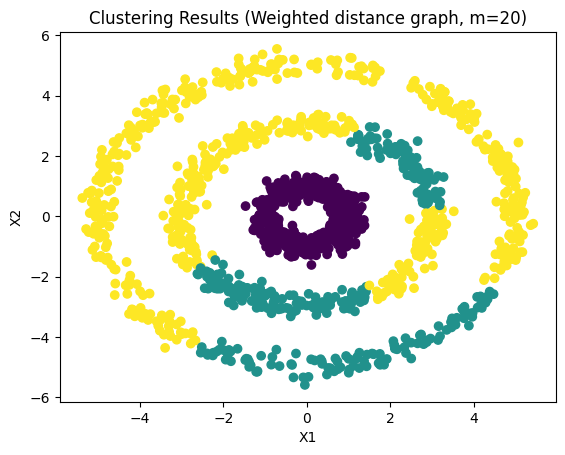

In [ ]:
m_values = [5, 10, 15, 20]

for m in m_values:
    # Fix σ2 = 0.1 for the bull’s eye data and σ2 = 0.01 for the halfmoons data.
    sigma_sq = 0.1
    L = get_wdg_laplacian(X, sigma_sq)
    V = get_normalized_embedding(L, m)

    # Fit k-means to V
    kmeans = KMeans(n_clusters=3, n_init=10)
    labels = kmeans.fit_predict(V)

    # Plot cluster results
    plot_cluster_results(X, labels, method=f"Weighted distance graph, m={m}")

> Based on the clustering results, the weighted distance graph the better than KNN graph. It partitions data into three clusters and correctly cluster the inner ring in most cases. Unlike KNN graph's 0 and 1 thresholds, weighted distance graph gives a very high weight to point that are extremely close and a near zero weight to points that are further away.

> Another interesting observation is that the weighted distance graph works better when m is higher. This is likely because when m is small, we are likely only using the first few eigenvectors. Those eigenvectors haven't captured enough of the global structure of the rings.

> When m is higher, the model can often cluster the inner ring correctly, but can still make mistakes on the outer rings. This is because the inner rain is more dense than the outer rings. As m increases, the model becomes more sensitive to local variations. If the outer rings are thinner or have points slightly further apart, the weighted connection becomes weak.

### Problem 2: Non-negative matrix factorization (NMF)

Given a non-negative data matrix $X \in \mathbb{R}^{n \times d}$, NMF seeks to approximate $X$ as $X \approx WH$, where $W \in \mathbb{R}^{n \times k}$, $H \in \mathbb{R}^{k \times d}$, and all entries of $W$ and $H$ are non-negative. The factorization is typically obtained by solving
$$\min_{W,H \ge 0} \|X - WH\|_F^2,$$
where $\|\cdot\|_F$ denotes the Frobenius norm. Each row of $W$ provides a low-dimensional representation (embedding) of a data point, while each row of $H$ corresponds to a basis component.

Load the classic Olivetti faces dataset using the `sklearn.datasets.fetch_olivetti_faces()` function. Reshape each image into a vector and construct the matrix of instances.

* **PCA Eigenfaces:**
    * Apply PCA and obtain the first 10 principal components.
    * Visualize the first 10 principal components as images, also known as eigenfaces.


In [ ]:
# Load data
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data
y = faces.target

# PCA
pca = PCA(n_components=0.95) # Retain 95% variance
pca.fit(X)
eigenfaces = pca.components_

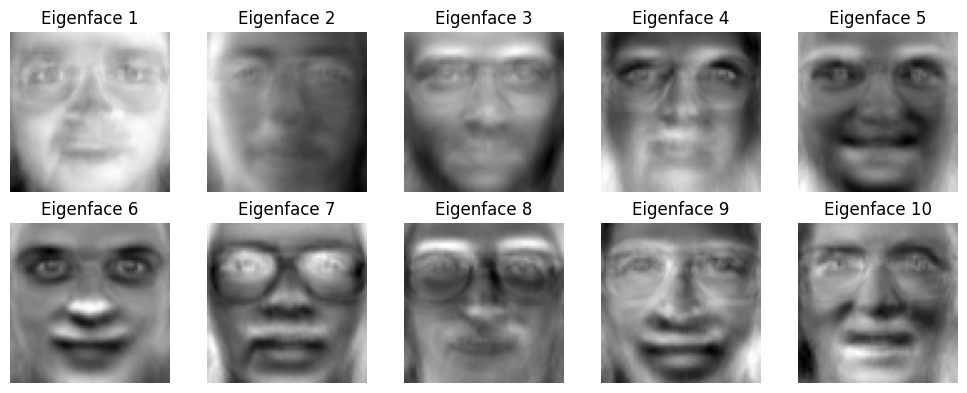

In [ ]:
# Visualize 10 eigenfaces
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i].reshape(64, 64), cmap='gray')
    ax.set_title(f'Eigenface {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

* **NMF Components:**
    * Apply NMF using 25 components, You might use the following Python code:
        ```python
        from sklearn.decomposition import NMF
        from sklearn.datasets import fetch_olivetti_faces

        faces = fetch_olivetti_faces(shuffle=True, random_state=42)
        X = faces.data
        n_components = 25

        nmf = NMF(
            n_components=n_components,
            init="nndsvda",
            max_iter=500,
            random_state=42
        )

        W = nmf.fit_transform(X)
        H = nmf.components_
        ```
    * Visualize the first 10 NMF components as images.
    * Comment on the differences observed between faces obtained from the NMF component and PCA principal components.


In [ ]:
n_components = 25

nmf = NMF(
    n_components=n_components,
    init="nndsvda",
    max_iter=500,
    random_state=42
)

W = nmf.fit_transform(X)
H = nmf.components_

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


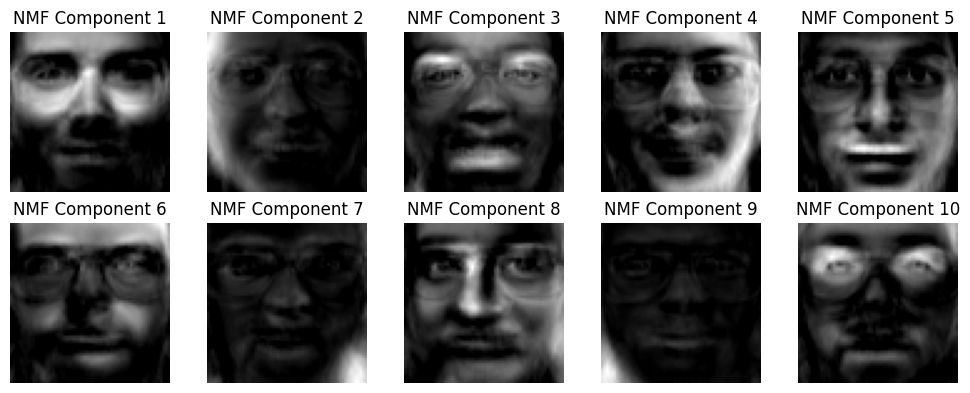

In [ ]:
# Visualize 10 NMF components
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(H[i].reshape(64, 64), cmap='gray')
    ax.set_title(f'NMF Component {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

> By observing the faces obtained from the NMF component
and PCA principal components, the NMF components look "darker" or more "sparse" compared to PCA eigenfaces. Some NMF components (e.g. NMF component 7 and NMF component 9) even look completely dark.

> This is because PCA components represent the direction of maximum variance, and the reconstruction is a linear combination where components can cancel each other out. This results this dense eigenfaces where almost every pixel has a non-zero value (positive or negative).

> On the other hand, NMF has the non-negative constraints and the reconstruction is purely additive. NMF decomposes data into localized parts, and this will make component images more sparse, resulting in distinct "patches" of facial features against a dark background.

* **Reconstruction comparison:** Select 5 test images. Reconstruct each image using:
    * PCA with 25 components
    * NMF with 25 components

Display the original image alongside its PCA and NMF reconstructions and comment. In addition to visualizing the differences in approximation quality, report the Frobenius norm (like the usual Euclidean squared or $\ell_2$ norm but for entries of a matrix) between each of these reconstructed images and the originals.

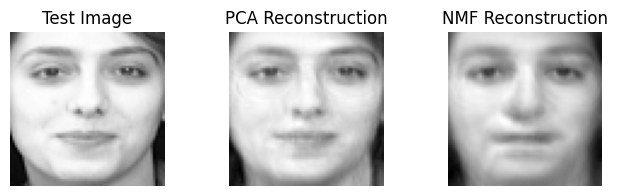

PCA Frobenius Norm Error: 1.94
NMF Frobenius Norm Error: 4.11


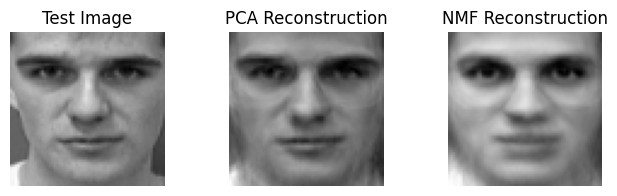

PCA Frobenius Norm Error: 1.72
NMF Frobenius Norm Error: 2.85


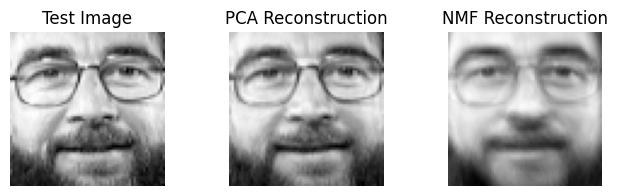

PCA Frobenius Norm Error: 2.07
NMF Frobenius Norm Error: 5.05


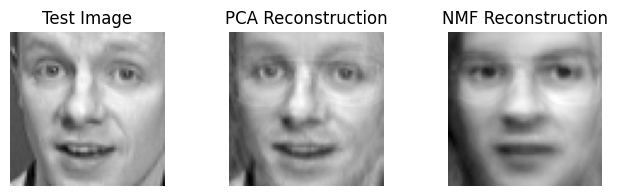

PCA Frobenius Norm Error: 2.04
NMF Frobenius Norm Error: 3.92


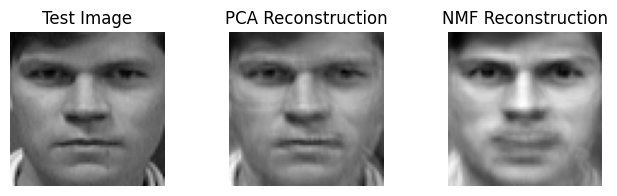

PCA Frobenius Norm Error: 1.84
NMF Frobenius Norm Error: 4.03


In [ ]:
# Random select 5 images from dataset
random_indices = np.random.choice(X.shape[0], size=5, replace=False)
test_images = X[random_indices]

# Reconstruction using PCA and NMF and plotting
def image_reconstruction(test_image, pca, nmf):
    """
    Reconstruct a single image using PCA and NMF and plot with original image
    """
    test_image = test_image.reshape(1, -1)

    # PCA reconstruction
    pca_reconstruction = pca.inverse_transform(pca.transform(test_image))

    # NMF reconstruction
    w_test = nmf.transform(test_image)
    nmf_reconstruction = np.dot(w_test, H)

    # Plotting
    images = [test_image, pca_reconstruction, nmf_reconstruction]
    titles = ['Test Image', 'PCA Reconstruction', 'NMF Reconstruction']
    fig, axes = plt.subplots(1, 3, figsize=(8, 2))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].reshape(64, 64), cmap='grey')
        ax.set_title(titles[i])
        ax.axis('off')
    plt.show()

    # Calculate Frobenius norms
    original = test_image.flatten()
    pca_error = norm(original - pca_reconstruction.flatten())
    nmf_error = norm(original - nmf_reconstruction.flatten())
    print(f"PCA Frobenius Norm Error: {pca_error:.2f}")
    print(f"NMF Frobenius Norm Error: {nmf_error:.2f}")


for image in test_images:
    image_reconstruction(image, pca, nmf)

> By comparing the reconstruction by PCA and NMF, we can observe that PCA does a better job in reconstruction of the image. PCA also show lower Frobenius norm error comparing to NMF.

### Problem 3. Visualizing SVD

1. Load the image “joe.jpg” provided, or an image of your
choosing into R or your language of choice (for best results avoid an image with any pure white backgrounds, related to “dividing by zero”). We’ve talked about how PCA is basically finding the best “rank $k$” approximation to a matrix such as your image. We’ve also mentioned that it is related to the singular value decomposition $X = UDV^T$ of a matrix, though we did not go into detail.

    Use the singular value decomposition on the matrix that contains the grayscale pixel values of your image. There are many ways one can code this, but one example of how to do load an image into a grayscale matrix $M$ using an R package:

    ```r
    library(imager)
    j <- load.image('joe.jpg')
    #plot(j)
    jj <- grayscale(j)
    #plot(jj)
    M <- scale(jj)
    ```



In [ ]:
joe_url = "https://raw.githubusercontent.com/YuranShi/biostat-285/refs/heads/main/hw2/joe.jpg"

# Use pillow library to open image
response = requests.get(joe_url)
if response.status_code == 200:
    joe_img = Image.open(BytesIO(response.content))
else:
    print(f"Failed to retrieve image. Status code: {response.status_code}")

# Convert joe_img to greyscale
joe_img = joe_img.convert("L")

# Get pixel matrix M
M = np.array(joe_img)
M = (M - np.mean(M)) / np.std(M) # scale the image like the R package above
M.shape

(1035, 920)

In [ ]:
# Perform SVD
U, D, Vt = svd(M)

2. What are the dimensions of the matrices $U, D, V$ (or $V^T$) in the SVD of your image? As a matrix, what is the rank of the image?



In [ ]:
# Get the dimension
print("U matrix shape:", U.shape)
print("D matrix shape: (Singular Values):", D.shape)
print("V transpose matrix shape:", Vt.shape)

# Get image rank
rank = np.count_nonzero(D > 1e-10)
print(f"\nThe rank of the image is: {rank}")

U matrix shape: (1035, 1035)
D matrix shape: (Singular Values): (920,)
V transpose matrix shape: (920, 920)

The rank of the image is: 920


3. The middle matrix $D$ is a diagonal matrix containing squared eigenvalues, and we mentioned that in PCA, the eigenvalue tells you “how important” that axis is in terms of how variance explained. Make a plot of how much of the “variance is explained” by the first $k$ singular vectors, choosing an appropriate x-axis so that you can see how many components $k$ should begin to capture the image well.



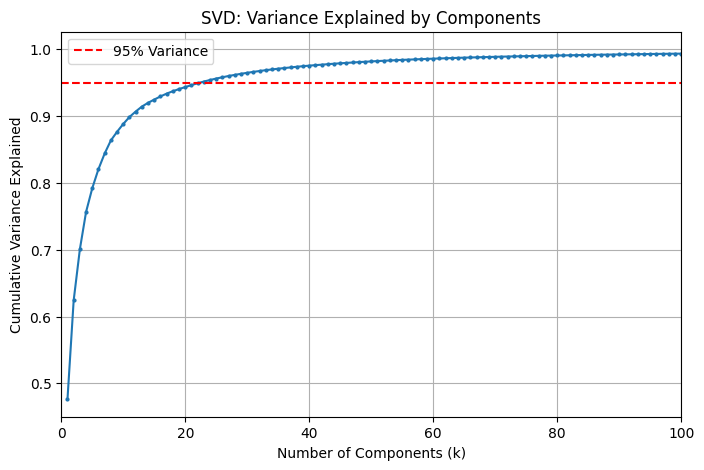

In [ ]:
# Get the cumulative variance explained
var_explained = D**2 / np.sum(D**2)
cum_var_explained = np.cumsum(var_explained)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var_explained) + 1), cum_var_explained, marker='o', markersize=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.xlim(0, 100)
plt.xlabel('Number of Components (k)')
plt.ylabel('Cumulative Variance Explained')
plt.title('SVD: Variance Explained by Components')
plt.legend()
plt.grid(True)
plt.show()

> Based on the plot of cumulative variance, around 22 components can capture 95% percent of the variance.



4. We have already done exercises visualizing reconstructions with $k$ principal components. We will show that reconstructing can be done “manually” from $U, D$, and $V$. First, set all but the first $k$ diagonal entries of the diagonal matrix $D$ to zero; calling this $D_k$, reconstruct by multiplying $\hat{X} = UD_kV^T$. Second, take only the first $k$ columns of $V$ and call this matrix $V_k$; reconstruct by multipling $\hat{X} = XV_kV_k^T$. Compare these plots for 3 values $k$ of your choosing, starting with $k = 5$ singular vectors and ranging up to a good value based on your findings in part 3.

In [ ]:
# Helper functions for reconstruction
def reconstruct_method_1(U, D, Vt, k):
    D_copy = D.copy()
    D_copy[k:] = 0
    # Since our image is not square, we need to construct Dk to match dim of U and Vt
    Dk = np.zeros((U.shape[1], Vt.shape[0]))
    np.fill_diagonal(Dk, D_copy)
    return U @ Dk @ Vt


def reconstruct_method_2(X, Vt, k):
    Vk_t = Vt[:k, :]
    return np.dot(X, np.dot(Vk_t.T, Vk_t))

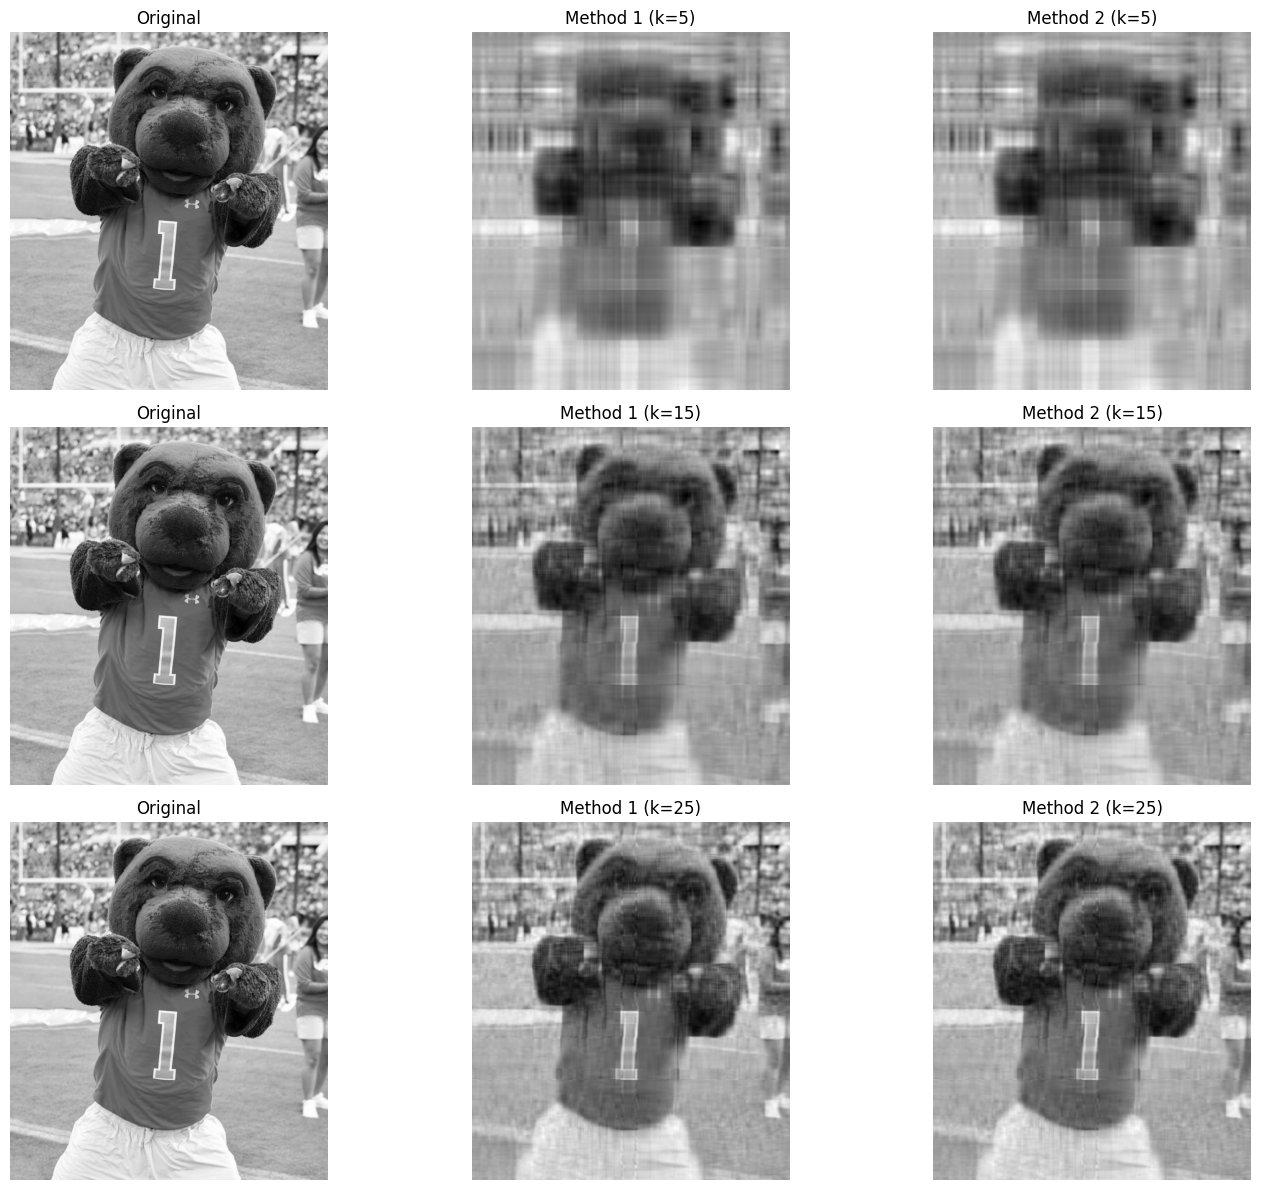

In [ ]:
k_values = [5, 15, 25]
fig, axes = plt.subplots(len(k_values), 3, figsize=(15, 12))

for i, k in enumerate(k_values):
    # Original image
    axes[i, 0].imshow(M, cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].set_axis_off()

    # Method 1
    rec1 = reconstruct_method_1(U, D, Vt, k)
    axes[i, 1].imshow(rec1, cmap='gray')
    axes[i, 1].set_title(f"Method 1 (k={k})")
    axes[i, 1].set_axis_off()

    # Method 2
    rec2 = reconstruct_method_2(M, Vt, k)
    axes[i, 2].imshow(rec2, cmap='gray')
    axes[i, 2].set_title(f"Method 2 (k={k})")
    axes[i, 2].set_axis_off()

plt.tight_layout()
plt.show()